Fresh dataset folders created.
Train path: dataset/train
Test path : dataset/test

Upload your dataset ZIP file now.


Saving Copy of devnagari digit.zip to Copy of devnagari digit.zip
Uploaded file: Copy of devnagari digit.zip
ZIP extracted to: raw_dataset

Extracted ZIP structure:
raw_dataset/
    DevanagariHandwrittenDigitDataset/
        Train/
            digit_2/
                40155.png
                40295.png
                66942.png
                56221.png
                18745.png
            digit_1/
                29147.png
                4835.png
                76499.png
                13461.png
                6903.png
            digit_5/
                77813.png
                5463.png
                67543.png
                41210.png
                41349.png
            digit_9/
                42515.png
                56823.png
                68616.png
                90137.png
                30721.png
            digit_7/
                68104.png
                30430.png
                41962.png
                30398.png
                49948.png
            digi

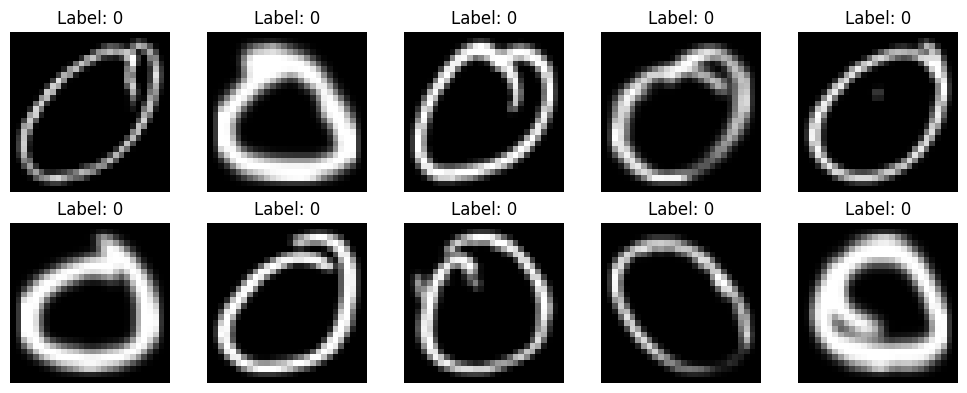

Reshaped x_train: (17000, 28, 28, 1)
Reshaped x_test: (3000, 28, 28, 1)
One-hot y_train: (17000, 10)
One-hot y_test: (3000, 10)

MODEL SUMMARY:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4865 - loss: 1.6291 - val_accuracy: 0.0000e+00 - val_loss: 7.0902
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8737 - loss: 0.5023 - val_accuracy: 0.0000e+00 - val_loss: 8.5022
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9326 - loss: 0.2520 - val_accuracy: 0.0000e+00 - val_loss: 9.2070
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9501 - loss: 0.1783 - val_accuracy: 0.0000e+00 - val_loss: 9.4747
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9594 - loss: 0.1419 - val_accuracy: 0.0000e+00 - val_loss: 9.8648


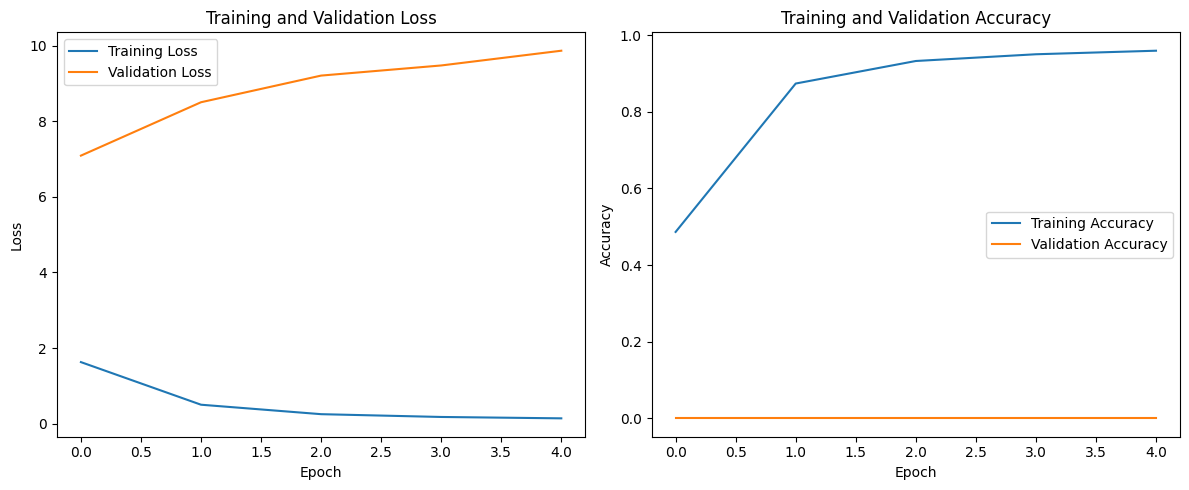

94/94 - 0s - 2ms/step - accuracy: 0.6587 - loss: 2.0766



Test Loss: 2.0766
Test Accuracy: 0.6587

Model saved as devnagari_fcn_model.h5
Saved model loaded successfully.
Loaded Model Test Loss: 2.0766
Loaded Model Test Accuracy: 0.6587
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels:      [0 0 0 0 0 0 0 0 0 0]


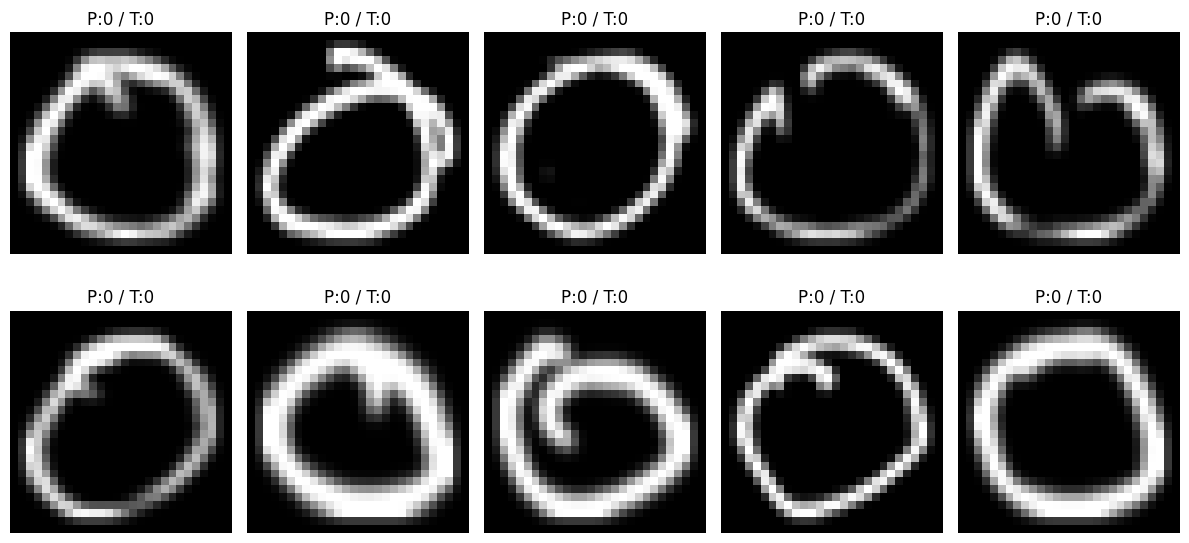


Total misclassified images: 1024


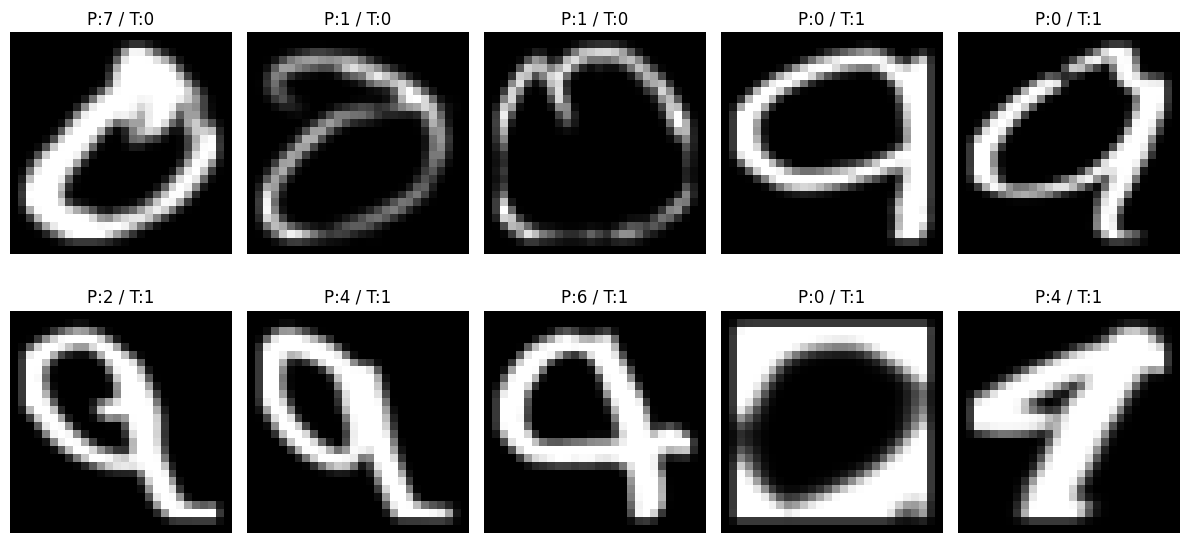

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Predicted label for first test image: 0
True label for first test image: 0


In [4]:
# ============================================================
# FULL COLAB-READY FCN CODE WITH ZIP UPLOAD
# Devanagari Digit Classification
# ============================================================

import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from google.colab import files

# ============================================================
# 1. SETTINGS
# ============================================================
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

img_height, img_width = 28, 28
num_classes = 10
batch_size = 128
epochs = 20

ALLOWED_EXTENSIONS = (".bmp", ".gif", ".jpeg", ".jpg", ".png", ".webp")

# ============================================================
# 2. CLEAN OLD DATASET
# ============================================================
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

extract_path = "raw_dataset"
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Fresh dataset folders created.")
print("Train path:", train_dir)
print("Test path :", test_dir)

# ============================================================
# 3. UPLOAD ZIP FILE
# ============================================================
print("\nUpload your dataset ZIP file now.")
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No ZIP file uploaded. Please upload a dataset ZIP file.")

zip_filename = list(uploaded.keys())[0]
print("Uploaded file:", zip_filename)

# ============================================================
# 4. EXTRACT ZIP
# ============================================================
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted to:", extract_path)

# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================
def get_class_names(folder):
    if not os.path.exists(folder):
        return []
    return sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])

def get_image_files(folder):
    if not os.path.exists(folder):
        return []
    return [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
        and f.lower().endswith(ALLOWED_EXTENSIONS)
    ]

def count_images(folder):
    total = 0
    for class_name in get_class_names(folder):
        class_path = os.path.join(folder, class_name)
        total += len(get_image_files(class_path))
    return total

def show_structure(folder):
    print(f"\nFolder structure for: {folder}")
    classes = get_class_names(folder)
    if not classes:
        print("  No class folders found.")
        return
    for class_name in classes:
        class_path = os.path.join(folder, class_name)
        print(f"  {class_name}: {len(get_image_files(class_path))} images")

def print_zip_structure(root_path):
    print("\nExtracted ZIP structure:")
    for root, dirs, files in os.walk(root_path):
        level = root.replace(root_path, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = " " * 4 * (level + 1)
        for f in files[:5]:
            print(f"{subindent}{f}")

def find_train_test_root(root_path):
    """
    Finds nested folder containing train/ and test/
    """
    for root, dirs, files in os.walk(root_path):
        dir_names = set(d.lower() for d in dirs)
        if "train" in dir_names and "test" in dir_names:
            actual_train = None
            actual_test = None

            for d in dirs:
                if d.lower() == "train":
                    actual_train = os.path.join(root, d)
                elif d.lower() == "test":
                    actual_test = os.path.join(root, d)

            if actual_train and actual_test:
                return actual_train, actual_test

    return None, None

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = get_class_names(folder)
    if len(class_names) == 0:
        raise ValueError(f"No class folders found inside: {folder}")

    class_map = {name: i for i, name in enumerate(class_names)}
    print(f"\nLoading from: {folder}")
    print("Class mapping:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        files = os.listdir(class_path)
        if len(files) == 0:
            print(f"Warning: empty class folder -> {class_path}")

        for filename in files:
            img_path = os.path.join(class_path, filename)

            if not os.path.isfile(img_path):
                continue
            if not filename.lower().endswith(ALLOWED_EXTENSIONS):
                continue

            try:
                img = Image.open(img_path).convert("L")        # grayscale
                img = img.resize((img_width, img_height))     # resize to 28x28
                img = np.array(img, dtype=np.float32) / 255.0 # normalize

                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path} because of error: {e}")

    if len(images) == 0:
        raise ValueError(f"No valid images found in: {folder}")

    return np.array(images), np.array(labels), class_names

# ============================================================
# 6. FIND train/test ROOT
# ============================================================
print_zip_structure(extract_path)

found_train, found_test = find_train_test_root(extract_path)

if found_train is None or found_test is None:
    raise ValueError(
        "Could not find train/test folders in the uploaded ZIP.\n"
        "Expected structure like:\n"
        "folder/train/class1/images...\n"
        "folder/test/class1/images..."
    )

print("\nDetected train folder:", found_train)
print("Detected test folder :", found_test)

# ============================================================
# 7. COPY DATA INTO dataset/train and dataset/test
# ============================================================
shutil.copytree(found_train, train_dir, dirs_exist_ok=True)
shutil.copytree(found_test, test_dir, dirs_exist_ok=True)

print("\nDataset copied into working train/test folders.")

# ============================================================
# 8. SHOW FINAL DATASET
# ============================================================
show_structure(train_dir)
show_structure(test_dir)

print("\nTrain image count:", count_images(train_dir))
print("Test image count :", count_images(test_dir))

if count_images(train_dir) == 0:
    raise ValueError("No images found in train directory.")
if count_images(test_dir) == 0:
    raise ValueError("No images found in test directory.")

# ============================================================
# 9. LOAD IMAGES
# ============================================================
x_train, y_train, train_classes = load_images_from_folder(train_dir)
x_test, y_test, test_classes = load_images_from_folder(test_dir)

if train_classes != test_classes:
    raise ValueError(
        f"Train and test class folders do not match.\n"
        f"Train classes: {train_classes}\n"
        f"Test classes : {test_classes}"
    )

print("\nOriginal train image shape:", x_train.shape)
print("Original test image shape:", x_test.shape)
print("Original y_train shape:", y_train.shape)
print("Original y_test shape:", y_test.shape)

# ============================================================
# 10. VISUALIZE SOME TRAINING IMAGES
# ============================================================
plt.figure(figsize=(10, 4))
samples_to_show = min(10, len(x_train))
for i in range(samples_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# ============================================================
# 11. RESHAPE + ONE HOT ENCODE
# ============================================================
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("Reshaped x_train:", x_train.shape)
print("Reshaped x_test:", x_test.shape)
print("One-hot y_train:", y_train_cat.shape)
print("One-hot y_test:", y_test_cat.shape)

# ============================================================
# 12. BUILD THE FCN MODEL
# ============================================================
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax")
])

print("\nMODEL SUMMARY:")
model.summary()

# ============================================================
# 13. COMPILE THE MODEL
# ============================================================
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# 14. TRAIN THE MODEL
# ============================================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_fcn_model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

history = model.fit(
    x_train,
    y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# 15. VISUALIZE TRAINING AND VALIDATION PERFORMANCE
# ============================================================
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 16. EVALUATE THE MODEL
# ============================================================
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# ============================================================
# 17. SAVE AND LOAD THE MODEL
# ============================================================
model.save("devnagari_fcn_model.h5")
print("\nModel saved as devnagari_fcn_model.h5")

loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")
print("Saved model loaded successfully.")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

# ============================================================
# 18. MAKE PREDICTIONS
# ============================================================
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)

print("\nFirst 10 predicted labels:", predicted_labels[:10])
print("First 10 true labels:     ", true_labels[:10])

# ============================================================
# 19. SHOW SOME TEST PREDICTIONS
# ============================================================
plt.figure(figsize=(12, 6))
samples_to_show = min(10, len(x_test))

for i in range(samples_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"P:{predicted_labels[i]} / T:{true_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 20. SHOW MISCLASSIFIED IMAGES
# ============================================================
misclassified_idx = np.where(predicted_labels != true_labels)[0]
print(f"\nTotal misclassified images: {len(misclassified_idx)}")

if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(misclassified_idx[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
        plt.title(f"P:{predicted_labels[idx]} / T:{true_labels[idx]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

# ============================================================
# 21. SINGLE IMAGE PREDICTION EXAMPLE
# ============================================================
sample_index = 0
sample_image = x_test[sample_index:sample_index + 1]
sample_prediction = loaded_model.predict(sample_image)
sample_label = np.argmax(sample_prediction, axis=1)[0]

print(f"\nPredicted label for first test image: {sample_label}")
print(f"True label for first test image: {true_labels[sample_index]}")